In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from random import randrange
from pandas import Series
from matplotlib import pyplot
import matplotlib.pyplot as plt

## Additive

In [4]:
series = [i+randrange(10) for i in range(1,100)]
series

[3,
 2,
 9,
 7,
 7,
 10,
 9,
 14,
 13,
 14,
 20,
 13,
 18,
 14,
 24,
 16,
 25,
 19,
 19,
 20,
 28,
 29,
 23,
 25,
 34,
 33,
 35,
 35,
 38,
 39,
 34,
 34,
 40,
 37,
 35,
 40,
 42,
 41,
 44,
 49,
 50,
 50,
 49,
 50,
 49,
 49,
 56,
 55,
 49,
 51,
 58,
 55,
 56,
 62,
 57,
 64,
 64,
 59,
 65,
 66,
 67,
 70,
 66,
 65,
 67,
 71,
 69,
 68,
 70,
 75,
 76,
 81,
 78,
 74,
 78,
 83,
 77,
 78,
 79,
 88,
 82,
 87,
 84,
 85,
 91,
 91,
 96,
 93,
 92,
 94,
 92,
 101,
 95,
 94,
 104,
 100,
 102,
 98,
 101]

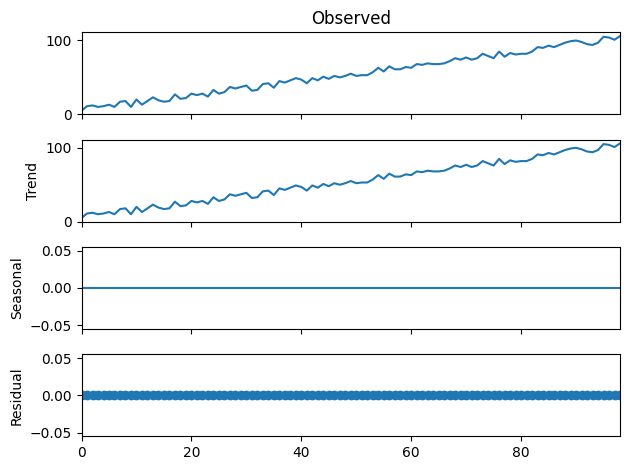

In [3]:
result = seasonal_decompose(series, model='additive', period=1)
result.plot()
pyplot.show()

## Multiplicative

In [6]:
series_2 = [i**2.0 for i in range(1,100)]
series_2

[1.0,
 4.0,
 9.0,
 16.0,
 25.0,
 36.0,
 49.0,
 64.0,
 81.0,
 100.0,
 121.0,
 144.0,
 169.0,
 196.0,
 225.0,
 256.0,
 289.0,
 324.0,
 361.0,
 400.0,
 441.0,
 484.0,
 529.0,
 576.0,
 625.0,
 676.0,
 729.0,
 784.0,
 841.0,
 900.0,
 961.0,
 1024.0,
 1089.0,
 1156.0,
 1225.0,
 1296.0,
 1369.0,
 1444.0,
 1521.0,
 1600.0,
 1681.0,
 1764.0,
 1849.0,
 1936.0,
 2025.0,
 2116.0,
 2209.0,
 2304.0,
 2401.0,
 2500.0,
 2601.0,
 2704.0,
 2809.0,
 2916.0,
 3025.0,
 3136.0,
 3249.0,
 3364.0,
 3481.0,
 3600.0,
 3721.0,
 3844.0,
 3969.0,
 4096.0,
 4225.0,
 4356.0,
 4489.0,
 4624.0,
 4761.0,
 4900.0,
 5041.0,
 5184.0,
 5329.0,
 5476.0,
 5625.0,
 5776.0,
 5929.0,
 6084.0,
 6241.0,
 6400.0,
 6561.0,
 6724.0,
 6889.0,
 7056.0,
 7225.0,
 7396.0,
 7569.0,
 7744.0,
 7921.0,
 8100.0,
 8281.0,
 8464.0,
 8649.0,
 8836.0,
 9025.0,
 9216.0,
 9409.0,
 9604.0,
 9801.0]

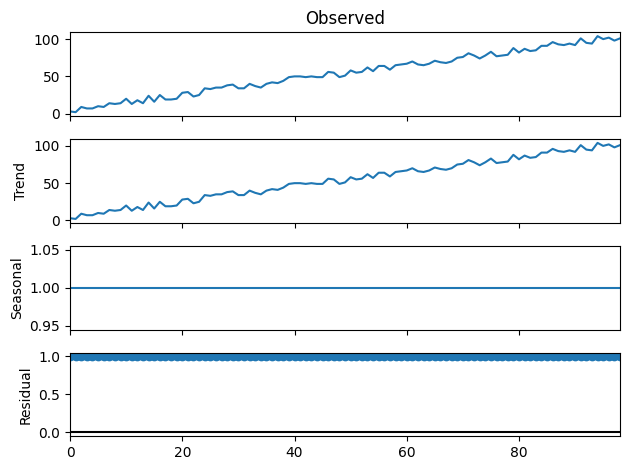

In [ ]:
result_2 = seasonal_decompose(series, model='multiplicative', period=1)
result_2.plot()
pyplot.show()

In [9]:
df=pd.read_csv('airline_passengers.csv')
 
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


<Axes: xlabel='Month'>

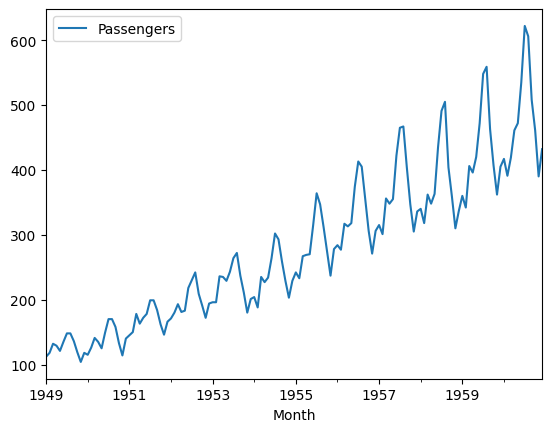

In [10]:
df.set_index('Month',inplace=True)
df.index=pd.to_datetime(df.index)
df.dropna(inplace=True)
df.plot()

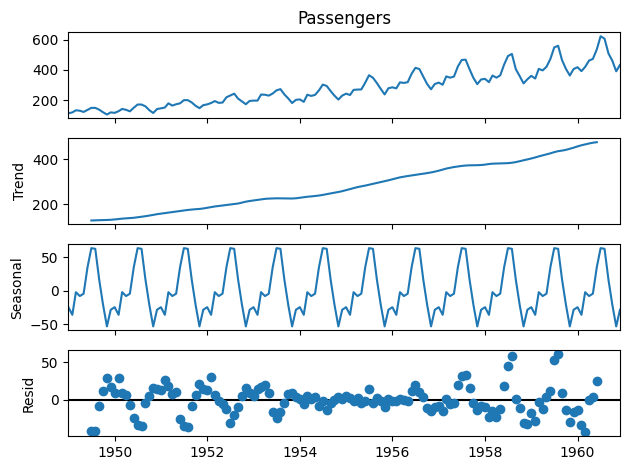

In [12]:
result_air=seasonal_decompose(df['Passengers'], model='additive', period=12)
result_air.plot()
pyplot.show()

<Axes: xlabel='Month'>

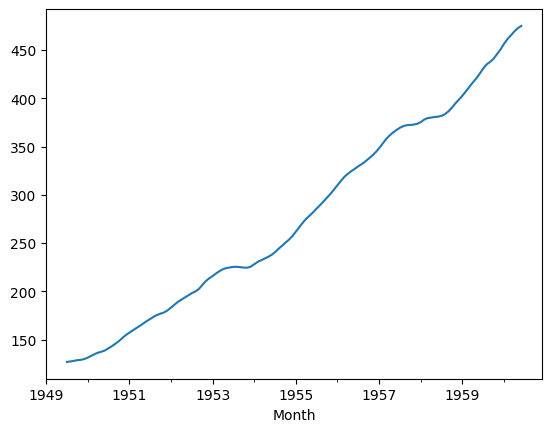

In [13]:
result_air.trend.plot()

<Axes: xlabel='Month'>

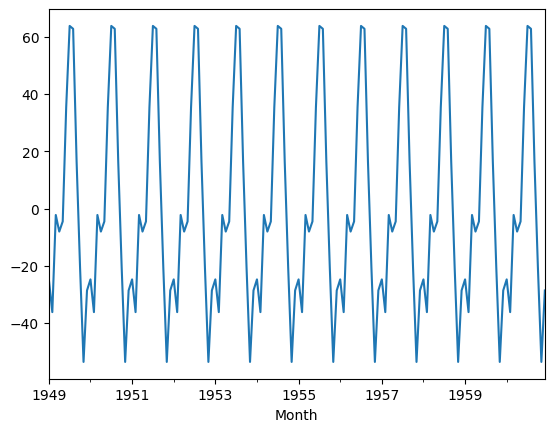

In [14]:
result_air.seasonal.plot()

<Axes: xlabel='Month'>

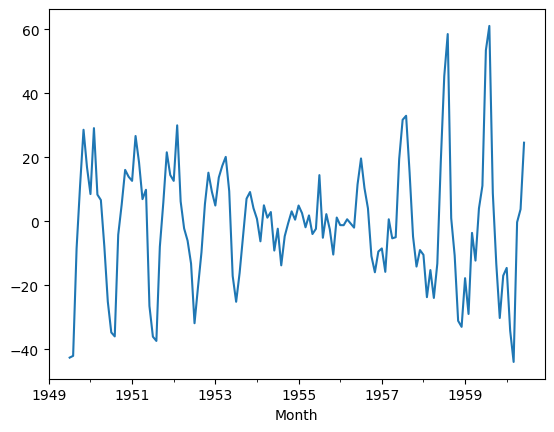

In [16]:
result_air.resid.plot()

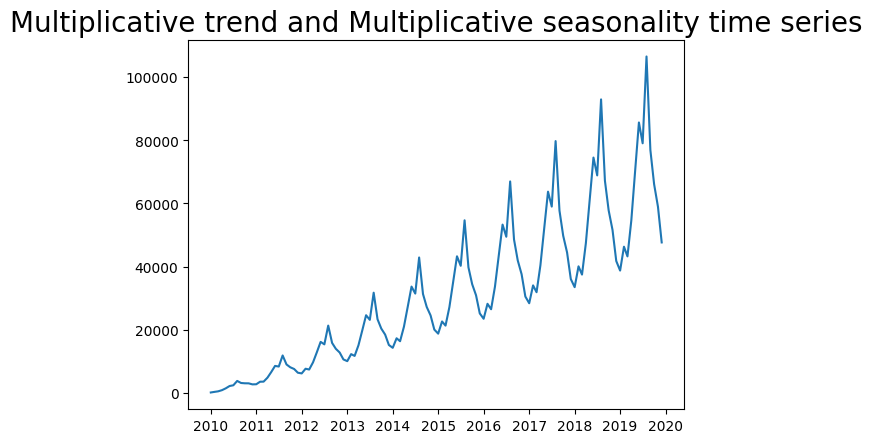

In [ ]:
# Single season multiplier factors - for seasonality effect
xs = np.arange(1, 121)
seasonal_multipliers = [110, 130, 120, 150, 190, 230, 210, 280, 200, 170, 150, 120]

# Raise to the 1.25 power to get upwards "curved" trend
x_range = np.array([x**1.25 for x in xs])

time_series = []
# Split to 10 chunks - 1 year each
for chunk in np.split(x_range, 10):
    for i, val in enumerate(chunk):
        # Multiply value with seasonal scalar
        time_series.append(val * seasonal_multipliers[i])
        
# Convert to DataFrame
df_mm = pd.DataFrame(
    data={'y': time_series}, 
    index=pd.date_range(start='2010-01-01', freq='MS', periods=120)
)

# Plot
plt.title('Multiplicative trend and Multiplicative seasonality time series', size=20)
plt.plot(df_mm);

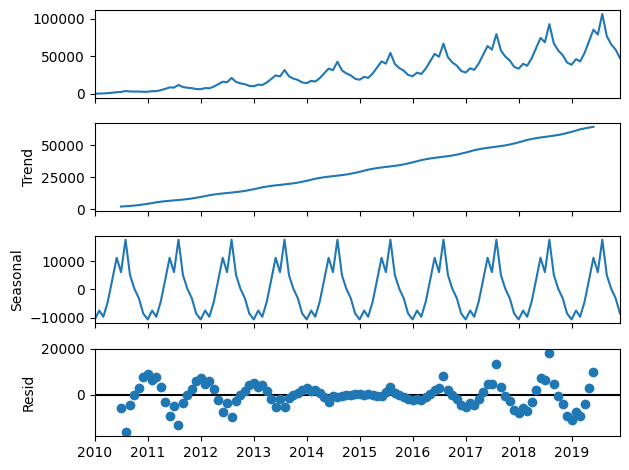

In [22]:
decomposed = seasonal_decompose(df_mm, model='additive')
decomposed.plot();

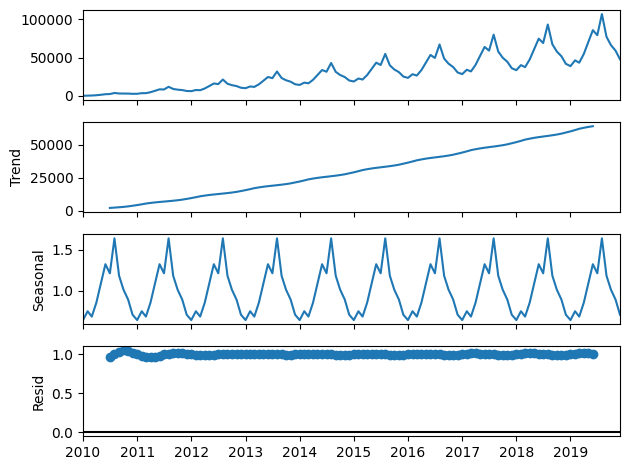

In [23]:
decomposed = seasonal_decompose(df_mm, model='multiplicative')
decomposed.plot();

# Since Residual Mean is almost constant so it is a multiplicative series